In [30]:
!pip install thop

In [31]:
import os
import time
from typing import Optional

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from thop import profile
import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS
import torchaudio.functional as F
import matplotlib.pyplot as plt

# 1. Реализация **LogMelFilterBanks**

In [3]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # general params and params defined by the exercise
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.window = torch.hann_window(self.window_length)

        # ---- STFT params ----
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # ---- Mel filterbank params ----
        self.f_min_hz = f_min_hz
        # torchaudio convention: if f_max is None, use sample_rate // 2
        self.f_max_hz = f_max_hz if f_max_hz is not None else float(samplerate // 2)
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        # finish parameters initialization
        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        # To access attributes, use self.<parameter_name>
        n_freqs = self.n_fft // 2 + 1
        return F.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale,
        )

    def spectrogram(self, x):
        # x - is an input signal
        return torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=self.window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex,
        )

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        # make comp stft
        stft_complex = self.spectrogram(x)

        # create power spec-m
        spec = stft_complex.abs().pow(self.power)

        # apply mel-filterbanks
        mel_spec = torch.matmul(
            spec.transpose(-1, -2), self.mel_fbanks
        ).transpose(-1, -2)

        return torch.log(mel_spec + 1e-6)

# 2. Сравнение с **torchaudio.transforms.MelSpectrogram**

In [7]:
# import os
# os.environ['TORCHAUDIO_USE_TORCHCODEC'] = '0'

wav_path = "test.wav" # path to test audio
signal, sr = torchaudio.load(wav_path)
assert sr == 16000, f"Expected 16 kHz, got {sr}"

Process by **torchaudio.transforms.MelSpectrogram**

In [8]:
melspec = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    hop_length=160,
    n_mels=80,
)(signal)

log_melspec_ref = torch.log(melspec + 1e-6)

Process by **LogMelFilterBanks**

In [9]:
logmelbanks = LogMelFilterBanks()(signal)

Check correctiveness of **LogMelFilterBanks** realisation

In [10]:
assert log_melspec_ref.shape == logmelbanks.shape, \
    f"Shape mismatch:\n correct: {log_melspec_ref.shape}\n got: {logmelbanks.shape}"
assert torch.allclose(log_melspec_ref, logmelbanks), \
    "Values do not match!"
print("Realisation is correct")

Realisation is correct


Build visualisation

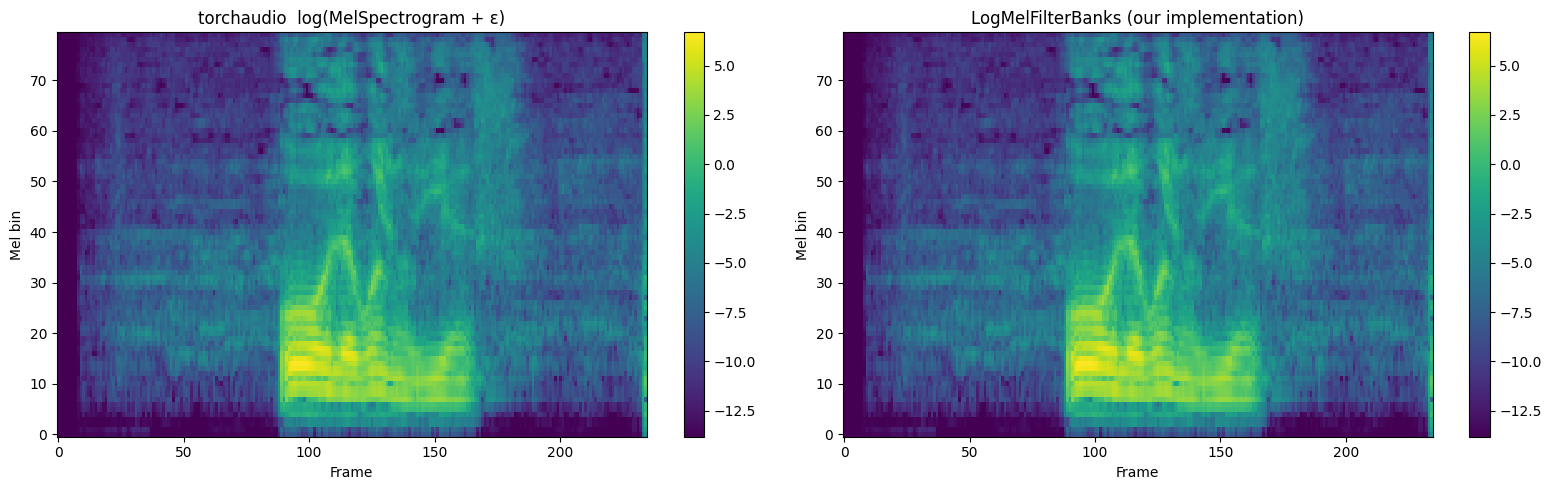

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(
    log_melspec_ref[0].detach().numpy(),
    aspect='auto', origin='lower', interpolation='none'
)
axes[0].set_title("torchaudio  log(MelSpectrogram + ε)")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Mel bin")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    logmelbanks[0].detach().numpy(),
    aspect='auto', origin='lower', interpolation='none'
)
axes[1].set_title("LogMelFilterBanks (our implementation)")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Mel bin")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig("logmelbanks_comparison.png", dpi=150)
plt.show()

# 3. Эксперименты с обучением на SpeechCommands (YES/NO)

Загрузим данные

In [22]:
class YesNoDataset(Dataset):
    LABEL_MAP = {"no": 0, "yes": 1}

    def __init__(self, subset: str, root: str = "./data", target_length: int = 16000):
        self.sc = SPEECHCOMMANDS(root, download=True, subset=subset)
        self.target_length = target_length

        self.sc._walker = [
            w for w in self.sc._walker
            if os.path.basename(os.path.dirname(w)) in self.LABEL_MAP
        ]

    def __len__(self):
        return len(self.sc._walker)

    def __getitem__(self, idx):
        waveform, sr, label, *_ = self.sc[idx]
        # pad / truncate до ровно 1 секунды
        if waveform.shape[1] < self.target_length:
            waveform = nnF.pad(waveform, (0, self.target_length - waveform.shape[1]))
        else:
            waveform = waveform[:, : self.target_length]
        return waveform.squeeze(0), self.LABEL_MAP[label]


class PrecomputedDataset(Dataset):

    def __init__(self, features: torch.Tensor, labels: torch.Tensor):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


@torch.no_grad()
def precompute_features(dataset, feature_extractor, batch_size=256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    all_f, all_l = [], []
    for wav, lab in loader:
        all_f.append(feature_extractor(wav))
        all_l.append(lab)
    return PrecomputedDataset(torch.cat(all_f), torch.cat(all_l))


print("Downloading / loading Speech Commands …")
os.makedirs("./data", exist_ok=True)
train_raw = YesNoDataset("training")
val_raw   = YesNoDataset("validation")
test_raw  = YesNoDataset("testing")
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")

100%|██████████| 2.26G/2.26G [00:30<00:00, 79.9MB/s]


Train: 6358  |  Val: 803  |  Test: 824


Структура сети

In [23]:
class SimpleCNN(nn.Module):

    def __init__(self, n_mels: int = 80, n_classes: int = 2, groups: int = 1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, 32, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.classifier(self.conv(x).squeeze(-1))

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def compute_flops(self, input_shape=(1, 80, 101)):
        dummy = torch.randn(input_shape)
        flops, _ = profile(self, inputs=(dummy,), verbose=False)
        return flops

Функции обучения

In [24]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n = 0.0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(feats), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        correct += (model(feats).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return correct / total


def run_experiment(
    model, train_ds, val_ds, test_ds,
    n_epochs=10, lr=1e-3, batch_size=64,
):
    model.to(device)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    hist = {"train_loss": [], "val_acc": [], "epoch_time": []}

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        loss = train_epoch(model, train_loader, optimizer, criterion)
        ep_time = time.time() - t0
        val_acc = evaluate(model, val_loader)

        hist["train_loss"].append(loss)
        hist["val_acc"].append(val_acc)
        hist["epoch_time"].append(ep_time)
        print(f"  Epoch {ep:2d}/{n_epochs} | Loss {loss:.4f} | "
              f"Val Acc {val_acc:.4f} | Time {ep_time:.2f}s")

    test_acc = evaluate(model, test_loader)
    hist["test_acc"] = test_acc
    print(f"  ► Test Accuracy: {test_acc:.4f}\n")
    return hist

Варьируем n_mels

In [27]:
import torch.nn.functional as nnF
import torchaudio.functional as AF

In [32]:
N_EPOCHS = 10
results_nmels = {}

for n_mels in [20, 40, 80]:
    print(f"\n{'=' * 55}")
    print(f"  n_mels = {n_mels}")
    print(f"{'=' * 55}")

    fe = LogMelFilterBanks(n_mels=n_mels)
    train_ds = precompute_features(train_raw, fe)
    val_ds   = precompute_features(val_raw,   fe)
    test_ds  = precompute_features(test_raw,  fe)

    model = SimpleCNN(n_mels=n_mels, groups=1)
    n_params = model.count_parameters()
    flops    = model.compute_flops(input_shape=(1, n_mels, 101))
    print(f"  Params: {n_params:,}  |  FLOPs: {flops:,.0f}")

    hist = run_experiment(model, train_ds, val_ds, test_ds, n_epochs=N_EPOCHS)
    hist["n_params"] = n_params
    hist["flops"]    = flops
    results_nmels[n_mels] = hist


  n_mels = 20
  Params: 20,962  |  FLOPs: 842,240
  Epoch  1/10 | Loss 0.2303 | Val Acc 0.9527 | Time 2.33s
  Epoch  2/10 | Loss 0.1118 | Val Acc 0.9726 | Time 2.11s
  Epoch  3/10 | Loss 0.0935 | Val Acc 0.9714 | Time 2.06s
  Epoch  4/10 | Loss 0.0624 | Val Acc 0.9726 | Time 2.07s
  Epoch  5/10 | Loss 0.0568 | Val Acc 0.9813 | Time 2.84s
  Epoch  6/10 | Loss 0.0532 | Val Acc 0.9826 | Time 2.14s
  Epoch  7/10 | Loss 0.0451 | Val Acc 0.9913 | Time 2.09s
  Epoch  8/10 | Loss 0.0423 | Val Acc 0.9838 | Time 2.06s
  Epoch  9/10 | Loss 0.0357 | Val Acc 0.9851 | Time 2.08s
  Epoch 10/10 | Loss 0.0283 | Val Acc 0.9888 | Time 2.39s
  ► Test Accuracy: 0.9927


  n_mels = 40
  Params: 22,882  |  FLOPs: 1,036,160
  Epoch  1/10 | Loss 0.2221 | Val Acc 0.9689 | Time 2.29s
  Epoch  2/10 | Loss 0.1047 | Val Acc 0.9601 | Time 2.97s
  Epoch  3/10 | Loss 0.0758 | Val Acc 0.9813 | Time 2.21s
  Epoch  4/10 | Loss 0.0626 | Val Acc 0.9813 | Time 2.18s
  Epoch  5/10 | Loss 0.0570 | Val Acc 0.9838 | Time 2.17s

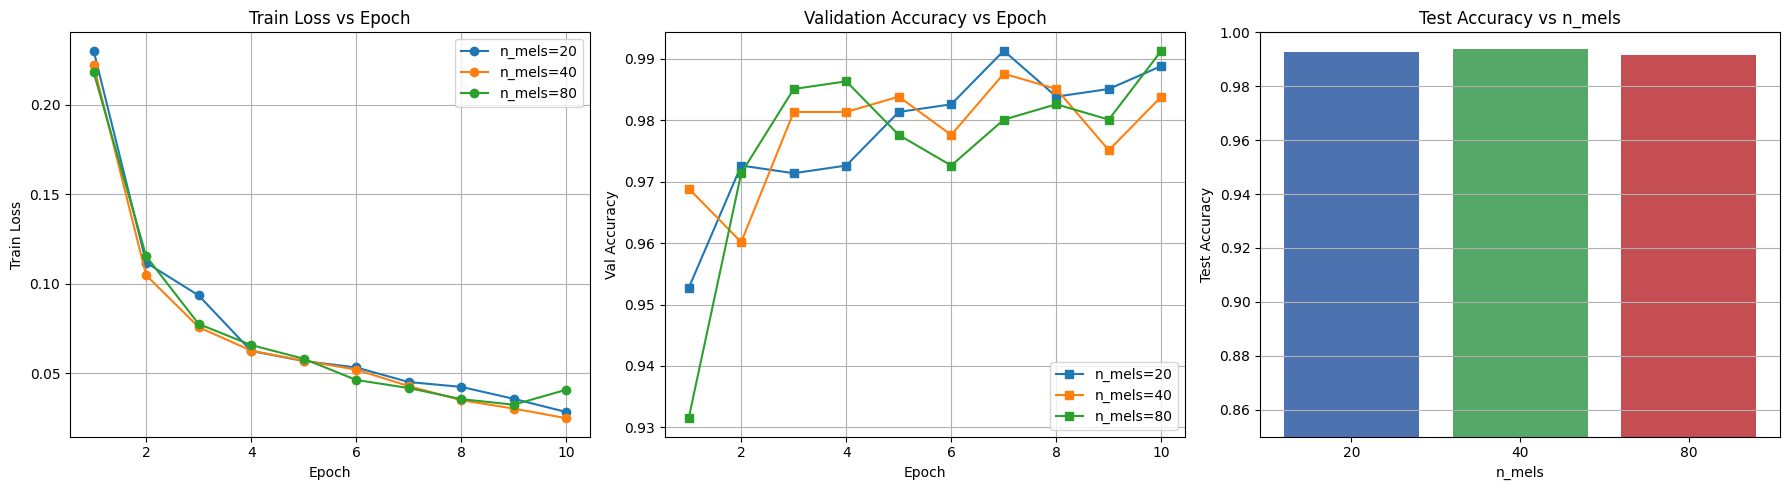

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Train loss
for nm, h in results_nmels.items():
    axes[0].plot(range(1, N_EPOCHS + 1), h["train_loss"], marker="o", label=f"n_mels={nm}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss")
axes[0].set_title("Train Loss vs Epoch"); axes[0].legend(); axes[0].grid(True)

# 2. Val accuracy
for nm, h in results_nmels.items():
    axes[1].plot(range(1, N_EPOCHS + 1), h["val_acc"], marker="s", label=f"n_mels={nm}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch"); axes[1].legend(); axes[1].grid(True)

# 3. Test accuracy bar
nms = list(results_nmels.keys())
axes[2].bar([str(n) for n in nms], [results_nmels[n]["test_acc"] for n in nms],
            color=["#4c72b0", "#55a868", "#c44e52"])
axes[2].set_xlabel("n_mels"); axes[2].set_ylabel("Test Accuracy")
axes[2].set_title("Test Accuracy vs n_mels"); axes[2].set_ylim(0.85, 1.0); axes[2].grid(axis="y")

plt.tight_layout(); plt.savefig("experiment_nmels.png", dpi=150); plt.show()

Варьируем groups

In [34]:
N_EPOCHS_G = 10
results_groups = {}

# признаки для n_mels=40 считаем один раз
fe80 = LogMelFilterBanks(n_mels=40)
train80 = precompute_features(train_raw, fe80)
val80   = precompute_features(val_raw,   fe80)
test80  = precompute_features(test_raw,  fe80)

for groups in [1, 2, 4, 8, 16]:
    print(f"\n{'=' * 55}")
    print(f"  groups = {groups}")
    print(f"{'=' * 55}")

    model = SimpleCNN(n_mels=80, groups=groups)
    n_params = model.count_parameters()
    flops    = model.compute_flops(input_shape=(1, 80, 101))
    print(f"  Params: {n_params:,}  |  FLOPs: {flops:,.0f}")

    hist = run_experiment(model, train80, val80, test80, n_epochs=N_EPOCHS_G)
    hist["n_params"] = n_params
    hist["flops"]    = flops
    results_groups[groups] = hist


  groups = 1
  Params: 26,722  |  FLOPs: 1,424,000
  Epoch  1/10 | Loss 0.2142 | Val Acc 0.9788 | Time 2.47s
  Epoch  2/10 | Loss 0.1045 | Val Acc 0.9290 | Time 3.12s
  Epoch  3/10 | Loss 0.0795 | Val Acc 0.9477 | Time 2.59s
  Epoch  4/10 | Loss 0.0740 | Val Acc 0.9639 | Time 2.44s
  Epoch  5/10 | Loss 0.0569 | Val Acc 0.9801 | Time 2.46s
  Epoch  6/10 | Loss 0.0452 | Val Acc 0.9851 | Time 2.43s
  Epoch  7/10 | Loss 0.0414 | Val Acc 0.9851 | Time 3.31s
  Epoch  8/10 | Loss 0.0362 | Val Acc 0.9826 | Time 2.47s
  Epoch  9/10 | Loss 0.0369 | Val Acc 0.9900 | Time 2.45s
  Epoch 10/10 | Loss 0.0277 | Val Acc 0.9863 | Time 2.45s
  ► Test Accuracy: 0.9854


  groups = 2
  Params: 13,666  |  FLOPs: 728,960
  Epoch  1/10 | Loss 0.2884 | Val Acc 0.9477 | Time 2.37s
  Epoch  2/10 | Loss 0.1396 | Val Acc 0.9141 | Time 2.61s
  Epoch  3/10 | Loss 0.0933 | Val Acc 0.9726 | Time 2.08s
  Epoch  4/10 | Loss 0.0751 | Val Acc 0.9776 | Time 2.08s
  Epoch  5/10 | Loss 0.0726 | Val Acc 0.9751 | Time 2.08s
 

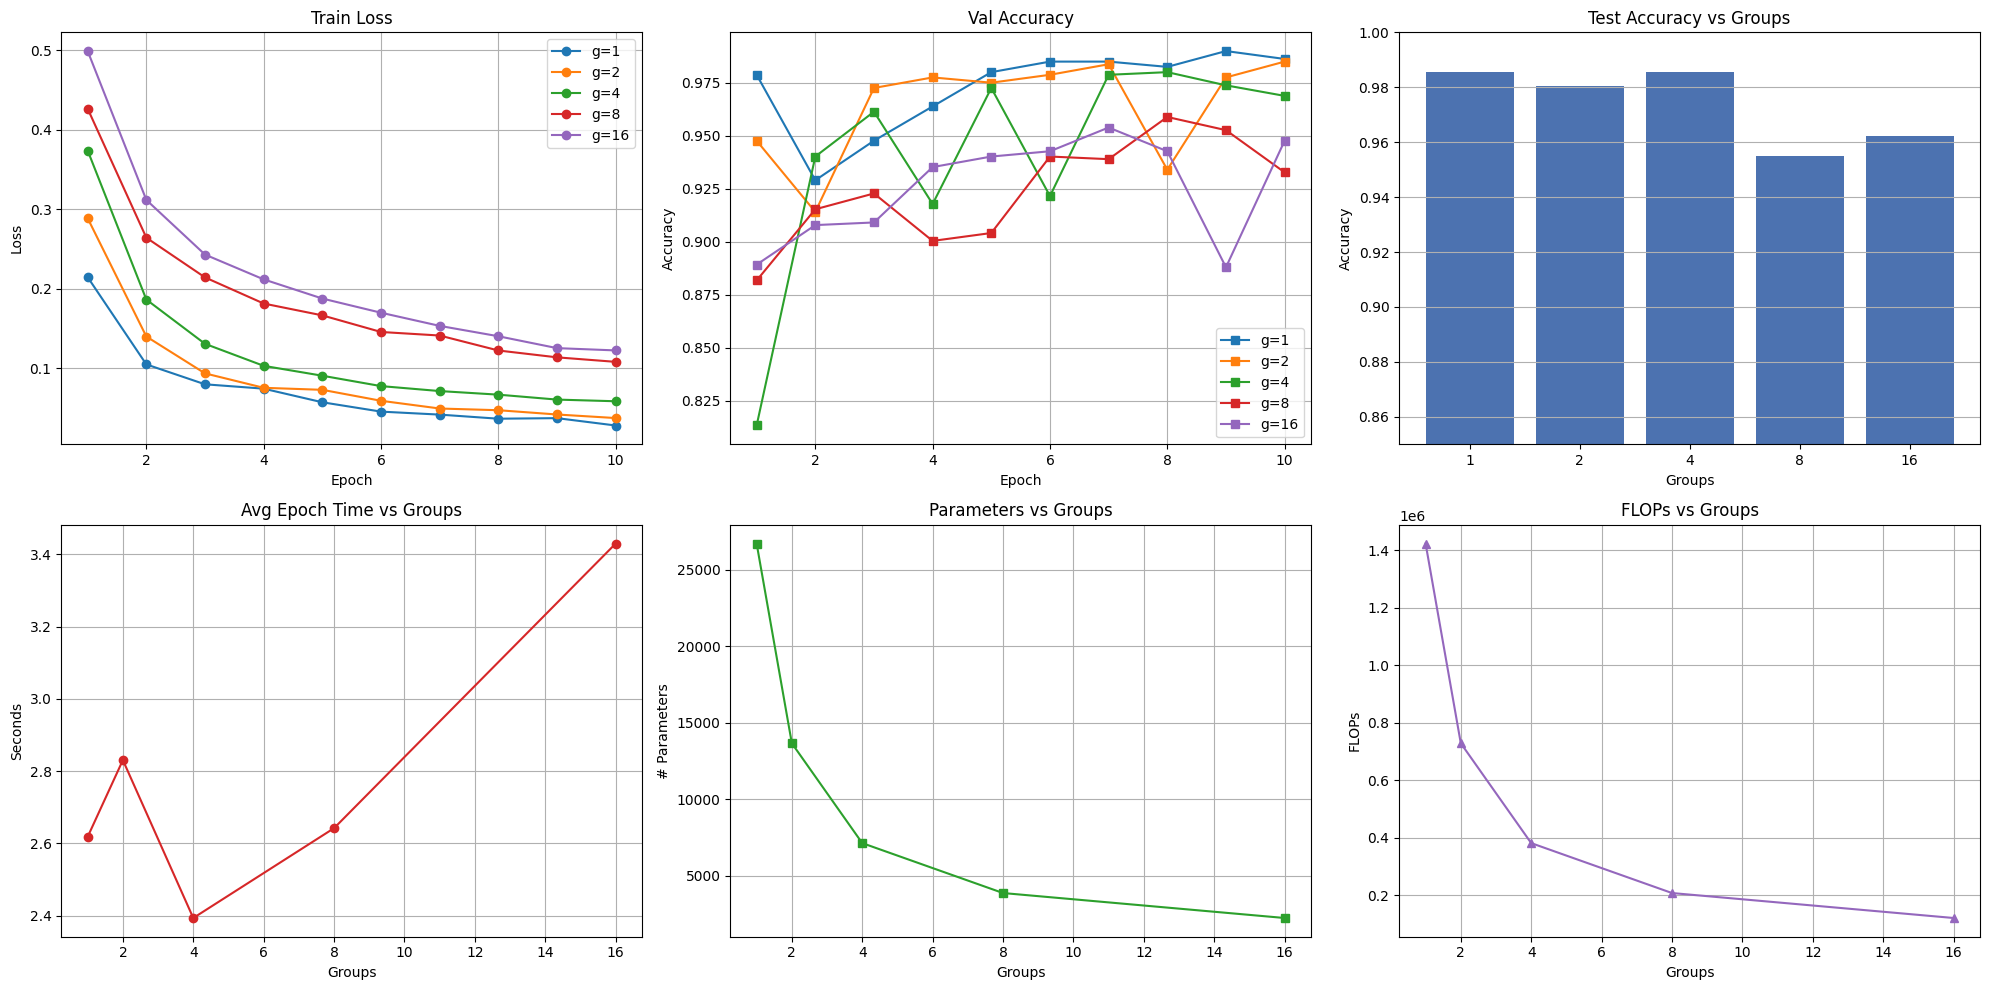

In [35]:
gvals = list(results_groups.keys())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 0, Col 0: train loss
for g, h in results_groups.items():
    axes[0, 0].plot(range(1, N_EPOCHS_G + 1), h["train_loss"], marker="o", label=f"g={g}")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Train Loss"); axes[0, 0].legend(); axes[0, 0].grid(True)

# Row 0, Col 1: val accuracy
for g, h in results_groups.items():
    axes[0, 1].plot(range(1, N_EPOCHS_G + 1), h["val_acc"], marker="s", label=f"g={g}")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Val Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(True)

# Row 0, Col 2: test accuracy bar
axes[0, 2].bar([str(g) for g in gvals],
               [results_groups[g]["test_acc"] for g in gvals], color="#4c72b0")
axes[0, 2].set_xlabel("Groups"); axes[0, 2].set_ylabel("Accuracy")
axes[0, 2].set_title("Test Accuracy vs Groups"); axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis="y")

# Row 1, Col 0: epoch time
avg_t = [np.mean(results_groups[g]["epoch_time"]) for g in gvals]
axes[1, 0].plot(gvals, avg_t, "o-", color="tab:red")
axes[1, 0].set_xlabel("Groups"); axes[1, 0].set_ylabel("Seconds")
axes[1, 0].set_title("Avg Epoch Time vs Groups"); axes[1, 0].grid(True)

# Row 1, Col 1: parameters
axes[1, 1].plot(gvals, [results_groups[g]["n_params"] for g in gvals], "s-", color="tab:green")
axes[1, 1].set_xlabel("Groups"); axes[1, 1].set_ylabel("# Parameters")
axes[1, 1].set_title("Parameters vs Groups"); axes[1, 1].grid(True)

# Row 1, Col 2: FLOPs
axes[1, 2].plot(gvals, [results_groups[g]["flops"] for g in gvals], "^-", color="tab:purple")
axes[1, 2].set_xlabel("Groups"); axes[1, 2].set_ylabel("FLOPs")
axes[1, 2].set_title("FLOPs vs Groups"); axes[1, 2].grid(True)

plt.tight_layout(); plt.savefig("experiment_groups.png", dpi=150); plt.show()

ИТОГ

In [36]:
print("=" * 70)
print("EXPERIMENT 1 — varying n_mels  (groups=1)")
print("=" * 70)
print(f"{'n_mels':>8} | {'Params':>10} | {'FLOPs':>14} | {'Test Acc':>10}")
print("-" * 52)
for nm, h in results_nmels.items():
    print(f"{nm:>8} | {h['n_params']:>10,} | {h['flops']:>14,.0f} | {h['test_acc']:>10.4f}")

print()
print("=" * 70)
print("EXPERIMENT 2 — varying groups  (n_mels=80)")
print("=" * 70)
print(f"{'groups':>8} | {'Params':>10} | {'FLOPs':>14} | {'Test Acc':>10} | {'Avg Time':>10}")
print("-" * 65)
for g, h in results_groups.items():
    at = np.mean(h["epoch_time"])
    print(f"{g:>8} | {h['n_params']:>10,} | {h['flops']:>14,.0f} | {h['test_acc']:>10.4f} | {at:>9.2f}s")

print()
print("Baseline model for next stage: n_mels=80, groups=1")

EXPERIMENT 1 — varying n_mels  (groups=1)
  n_mels |     Params |          FLOPs |   Test Acc
----------------------------------------------------
      20 |     20,962 |        842,240 |     0.9927
      40 |     22,882 |      1,036,160 |     0.9939
      80 |     26,722 |      1,424,000 |     0.9915

EXPERIMENT 2 — varying groups  (n_mels=80)
  groups |     Params |          FLOPs |   Test Acc |   Avg Time
-----------------------------------------------------------------
       1 |     26,722 |      1,424,000 |     0.9854 |      2.62s
       2 |     13,666 |        728,960 |     0.9806 |      2.83s
       4 |      7,138 |        381,440 |     0.9854 |      2.39s
       8 |      3,874 |        207,680 |     0.9551 |      2.64s
      16 |      2,242 |        120,800 |     0.9624 |      3.43s

Baseline model for next stage: n_mels=80, groups=1
